# Using a trained reflectorch model

In the first subsection, we show how to use the inference class (which abstracts away the implementation details) on experimental data.

In the last subsection, we illustrate some implementation details involved in using a trained model (which resembles the steps performed during the training process, including the generation of synthetic data). 

## Simplified use of a trained reflectorch model on experimental data

In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from reflectorch import InferenceModel, Layer, Structure, Backing, EXP_DATA_DIR
from reflectorch.inference.plotting import print_prediction_results, plot_reflectivity

torch.manual_seed(0); # set seed for reproducibility

The `InferenceModel` class simplifies the inference step for single reflectivity curves. We initialize the inference model by providing the name of the configuration file of a pretrained model (`config_name`), either with or without the '.yaml' extension. By default, the file name of the saved model weights for a specific configuration has the format 'model_' + config_name + extension (either '.pt' or '.safetensors'), but a different file name can be specified via the `model_name` argument. The `root_dir` argument can be used to specify a project directory containing the `configs` and `saved_models` subdirectories (containing the configurations and model weights, respectively), if different from the default package directory. The `weights_format` argument specifies the format (and extension) of the weights file, which can be either 'pt' (the default Pytorch weight format) or 'safetensors' (a weight format which addresses security risks associated with the default Pytorch weight format, as recommended for sharing via Huggingface). If the configuration or weights files are not found locally, they can be downloaded automatically from the Huggingface repository specified with the `repo_id` argument (['valentinsingularity/reflectivity'](https://huggingface.co/valentinsingularity/reflectivity/tree/main) is the current default research repository, and ['reflectorch-ILL'](https://huggingface.co/reflectorch-ILL) is a repository for selected NR models). Additionally, the `device` argument can be set to either `cuda` (for inference on the GPU) or `cpu` (for computers without a GPU with CUDA support).

:::{note}
`EasyInferenceModel` is an alias of the `InferenceModel` class which was used in previous versions of the package.
:::

We create an instance of the inference class, which also prints some details about the model such as the parameter ranges.

In [34]:
#config_name = 'b_mc_point_xray_conv_standard_L2_InputQ' ### older model without q_shift and r_scale as predicted parameters
config_name = 'g_mc_point_xray_intconv_standard_L2_InputQ_size1024' ### newer model

inference_model = InferenceModel(
    config_name=config_name,
    model_name=None,
    root_dir=None,
    repo_id='valentinsingularity/reflectivity',
    device='cpu',
)

Configuration file `/home/vmunteanu/Jupyter Notebooks/Reflectivity/reflectorch/configs/g_mc_point_xray_intconv_standard_L2_InputQ_size1024.yaml` found locally.
Weights file `/home/vmunteanu/Jupyter Notebooks/Reflectivity/reflectorch/saved_models/model_g_mc_point_xray_intconv_standard_L2_InputQ_size1024.safetensors` found locally.
Model g_mc_point_xray_intconv_standard_L2_InputQ_size1024 loaded. Number of parameters: 21.98 M
The model corresponds to a `standard_model` parameterization with 2 layers (10 predicted parameters)
Parameter types and total ranges:
- thicknesses: [1.0, 500.0]
- roughnesses: [0.0, 60.0]
- slds: [0.0, 50.0]
- q_shift: [-0.002, 0.002]
- r_scale: [0.9, 1.1]
Allowed widths of the prior bound intervals (max-min):
- thicknesses: [0.01, 500.0]
- roughnesses: [0.01, 60.0]
- slds: [0.01, 5.0]
- q_shift: [1e-05, 0.004]
- r_scale: [0.001, 0.2]
The following quantities are additional inputs to the network: prior bounds.


We consider the following XRR curve (already preprocessed by standard procedures such as footprint correction):

In [35]:
data = np.loadtxt(EXP_DATA_DIR / 'data_PTCDI-C3.txt', delimiter='\t', skiprows=1)
q_exp = data[..., 0]
curve_exp = data[..., 1]

print(curve_exp.shape, q_exp.shape, q_exp.min(), q_exp.max())

(141,) (141,) 0.0142368058 0.213456644


This is a measurement for a two-layer film in which we have some prior knowlede about the investigated system. We know the substrate is silicon on top of which sits a thin silicon oxide layer, followed by a perylene diimide (PTCDI-C3) layer. Thus, we can set narrow prior bounds for the scattering length densities (around known value for these materials) and for the thickness of the silicon oxide layer, but we set wide prior bounds for the roughnesses and for the thickness of the perylene diimide layer. We specify the prior bounds for the parameters as a list of tuples `(min_prior_bound, max_prior_bound)`. 

In [36]:
prior_bounds = [
    (1., 400.), #layer thicknesses (top to bottom)
    (1., 10.), 

    (0., 20.), #interlayer roughnesses (top to bottom)
    (0., 15.), 
    (0., 15.),

    (10., 13.), #real layer slds (top to bottom)
    (20., 21.), 
    (20., 21.),

    (-0.002, 0.002), #q_shift
    (0.9, 1.1), #r_scale
]

Now, we can call the `preprocess_and_predict` method of the inference model and provide as input the reflectivity curve and the prior bounds in order to obtain the neural network predictions (this will apply preprocessing steps to the data as required for constructing the neural network input, such as interpolation or padding, then use the `predict` method internally, which was main inference method in older versions of the package). If the `clip_prediction` argument is `True`, the predictions are clipped to ensure they are not outside the interval defined by the prior bounds. If the `polish_prediction` argument is `True`, the predictions are further polished using a conventional least mean squares (LMS) fit. Additionally,  if `fit_growth` is also `True`, an additional parameter is introduced during the LMS polishing to account for the change in the thickness of the upper layer during the in-situ measurement of the reflectivity curve during film deposition (necessary when the aquisition rate is slow compared to the growth rate), the maximum possible change being given by the `max_d_change` argument. The method returns a dictionary containing the predicted parameters (both as a BasicParams object and as a Numpy array). If `calc_pred_curve` is `True`, the reflectivity curve corresponding to the predicted parameters is also computed and added to the dictionary (also the case for the `calc_pred_sld_profile` and `calc_polished_sld_profile` arguments). The arguments `sld_profile_padding_left` and `sld_profile_padding_left` control the amount of padding applied to the computed SLD profile. Several other arguments of `preprocess_and_predict` method are documented in the NR-specific tutorial.

In [37]:
prediction_dict = inference_model.preprocess_and_predict(
    reflectivity_curve=curve_exp,
    prior_bounds=prior_bounds,
    q_values=q_exp,
    clip_prediction=True,
    polish_prediction=True,
    calc_pred_curve=True,
    calc_pred_sld_profile=True,
    calc_polished_sld_profile=True,
    sld_profile_padding_left=0.4,
    sld_profile_padding_right=1.3,
)

pred_params = prediction_dict['predicted_params_array']
pred_curve = prediction_dict['predicted_curve']
polished_curve = prediction_dict['polished_curve']
q_plot = prediction_dict['q_plot_pred']

In [38]:
print_prediction_results(prediction_dict)

Parameter        Predicted    Polished
--------------------------------------
Thickness L1       191.755     190.392
Thickness L2        10.000      10.000
Roughness L1        20.000      20.000
Roughness L2         3.409       3.835
Roughness sub       10.062      15.000
SLD L1              12.059      11.330
SLD L2              20.586      20.396
SLD sub             20.328      20.000
q_shift             -0.000      -0.001
r_scale              0.977       0.919


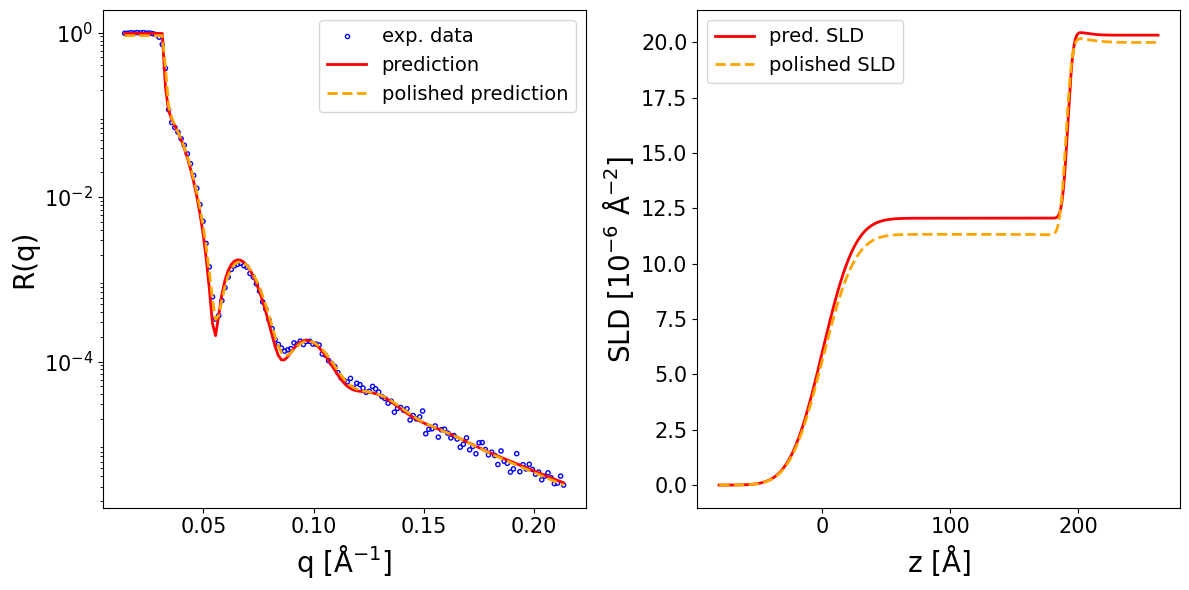

In [39]:
fig, ax = plot_reflectivity(
    q_exp=q_exp, r_exp=curve_exp,
    q_pred=q_plot, r_pred=pred_curve,
    q_pol=q_exp, r_pol=polished_curve,

    plot_sld_profile=True, z_sld=prediction_dict['predicted_sld_xaxis'],
    sld_pred=prediction_dict['predicted_sld_profile'],
    sld_pol=prediction_dict['sld_profile_polished'],
)

:::{note}
In older versions of the package, the `predict` method was used, which expects as input data already interpolated to the specific discretization required by the model.
This can be done using the `interpolate_data_to_model_q` method.

```python

q_model, exp_curve_interp = inference_model.interpolate_data_to_model_q(q_exp, curve_exp)

prediction_dict = inference_model.predict(
    reflectivity_curve=exp_curve_interp,
    prior_bounds=prior_bounds,
    q_values=q_model,
)
``` 
:::

Now we make a prediction for a similar structure, except that the top layer is fullerene (C60), thus we only change the prior bounds for the SLD of this layer. Here, we also illustrate an alternative way to provide the prior bounds. Instead of manually defining the list of prior bounds, one can also define ``Layer`` objects containing the prior bounds of the parameters, which are stacked in a ``Structure`` object which computes internally the list of prior bounds in the format expected by the inference method.

In [40]:
data = np.loadtxt(EXP_DATA_DIR / 'data_C60.txt', delimiter='\t', skiprows=1)
q_exp = data[..., 0]
curve_exp = data[..., 1]

In [41]:
C60_layer = Layer(thickness_bounds=(1, 400), roughness_bounds=(0, 20), sld_bounds=(13, 18))
SiOx_layer = Layer(thickness_bounds=(1, 10), roughness_bounds=(0, 15), sld_bounds=(20, 21))
Si_substrate = Backing(roughness_bounds=(0, 15), sld_bounds=(20, 21))

structure = Structure(
    layers=[C60_layer, SiOx_layer, Si_substrate],
    q_shift_bounds=(-0.002, 0.002),
    r_scale_bounds=(0.9, 1.1),
)

prior_bounds = structure.prior_bounds
print(prior_bounds)

[(1, 400), (1, 10), (0, 20), (0, 15), (0, 15), (13, 18), (20, 21), (20, 21), (-0.002, 0.002), (0.9, 1.1)]


One can also use the `validate_parameters_and_ranges` method to check that the provided prior bounds are compatible with the loaded model. This method checks that:

- the number of layers matches the model’s expected number
- each layer’s thickness, roughness and SLD bounds are within the model’s training ranges
- the SLD bound width does not exceed the maximum training width
- any nuisance parameters expected by the model (e.g. q_shift, r_scale, log10_background) are provided and within training bounds

In [42]:
structure.validate_parameters_and_ranges(inference_model)

All checks passed.


In [43]:
prediction_dict = inference_model.preprocess_and_predict(
    reflectivity_curve=curve_exp,
    prior_bounds=prior_bounds,
    q_values=q_exp,
    clip_prediction=True,
    polish_prediction=True,
    calc_pred_curve=True,
    calc_pred_sld_profile=True,
    calc_polished_sld_profile=True,
    sld_profile_padding_left=0.3,
    sld_profile_padding_right=1.3,
)

pred_params = prediction_dict['predicted_params_array']
pred_curve = prediction_dict['predicted_curve']
polished_curve = prediction_dict['polished_curve']
q_plot = prediction_dict['q_plot_pred']

Parameter        Predicted    Polished
--------------------------------------
Thickness L1       166.455     161.832
Thickness L2        10.000      10.000
Roughness L1         7.933       7.188
Roughness L2         5.502       2.747
Roughness sub       10.074      12.914
SLD L1              14.316      14.435
SLD L2              20.817      20.000
SLD sub             20.408      21.000
q_shift              0.001       0.000
r_scale              0.957       0.959


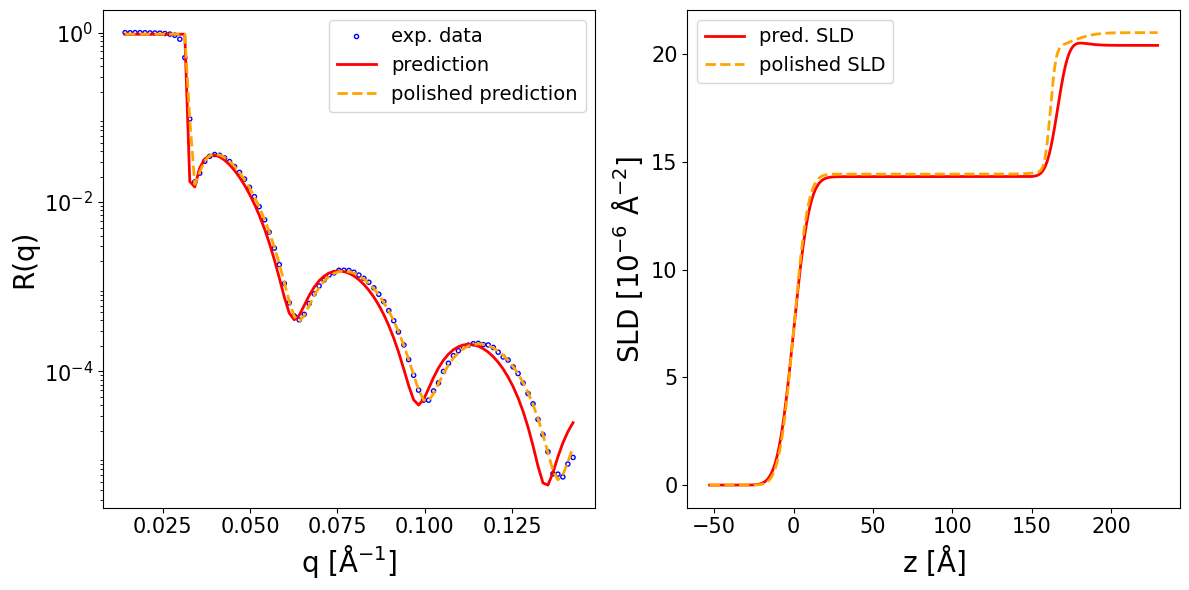

In [44]:
print_prediction_results(prediction_dict)

fig, ax = plot_reflectivity(
    q_exp=q_exp, r_exp=curve_exp,
    yerr=None, xerr=None,
    q_pred=q_plot, r_pred=pred_curve,
    q_pol=q_exp, r_pol=polished_curve,

    plot_sld_profile=True, z_sld=prediction_dict['predicted_sld_xaxis'],
    sld_pred=prediction_dict['predicted_sld_profile'],
    sld_pol=prediction_dict['sld_profile_polished'],
)

## Available models

The neural network weights for available pretrained models together with their corresponding configuration files can be found on the research-oriented Huggingface repository ['valentinsingularity/reflectivity'](https://huggingface.co/valentinsingularity/reflectivity/tree/main). There, the configuration files are organized in the `configs` directory and the network weights in the `saved_models` directory, which resembles the file structure of the package. The name of the configuration files have a format such as `b_mc_point_xray_conv_standard_L1_InputQ.yaml` or `g_mc_point_neutron_intconv_standard_L2_InputQDq_size1024.yaml`. Here, the first letter signifies the model generation, newer models having a letter higher in the alphabet. Then, `xray` or `neutron` identifies the model as being for XRR or NR data. Here, `standard` stands for the standard box / slab parameterization of the SLD profile and `L` shows the number of layers of the physical structure (fronting and backing not included). `InputQ` means that the q values are an additional input to the neural network, such that the models work for variable q ranges, while `InputQDq` in the case of a NR model means that the q-resolution is also an input provided to the neural network. The type of embedding network is specified in the name, such as `conv` for 1D CNN or `intconv` for a newer embedding network based on integral convolution. Configuration files with names such as `mc#` or `mc-o#` correspond to older models that are now outdated.

A second Huggingface repository is ['reflectorch-ILL'](https://huggingface.co/reflectorch-ILL), which contains a smaller number of selected NR models, mainly targeting use cases relevant at the Institut Laue-Langevin (ILL). Here, the file organization structure is different, a configuration file being grouped together with its neural network weights file and having a Model Card with metadata (e.g. https://huggingface.co/reflectorch-ILL/NR-2layers-basic-v1). Also the file name is simplified (e.g. `NR-2layers-basic-v1 `).

The configuration files available on Huggingface can be filtered based on their properties using the `HuggingfaceQueryMatcher` class. We first initialize an instance of the query matcher which first downloads the configuration files to a temporary directory (it can take around 1 minute).

In [45]:
from reflectorch import HuggingfaceQueryMatcher

hf_query_matcher = HuggingfaceQueryMatcher(repo_id='valentinsingularity/reflectivity')

Temporary directory created at: /tmp/tmplgy4rg78


Then we can provide a query (i.e. a dictionary of key-value pairs) as argument to its `get_matching_configs` method to get a list of configurations which match that query. The query should be formatted according to the hierarchical structure of the YAML configuration files (which are described in detail in the following sections of the documentation). 

For keys containing the ``param_ranges`` subkey a configuration is selected if the value of the query (i.e. desired parameter range) is a subrange of the parameter range in the configuration, in all other cases the values must match exactly.

In [46]:
query = {
    'dset.prior_sampler.kwargs.max_num_layers': 2,
    'model.network.cls': 'NetworkWithPriors',
    'model.network.kwargs.mlp_activation': 'gelu',
}

matching_configs = hf_query_matcher.get_matching_configs(query)
for config in matching_configs:
    print(config)

NR-2layers-basic-v1.yaml
b_mc_point_neutron_conv_standard_L2_InputQDq.yaml
b_mc_point_xray_conv_standard_L2.yaml
b_mc_point_xray_conv_standard_L2_InputQ.yaml
e_mc_point_neutron_conv_standard_L2_InputQDq_n128_size1024.yaml
e_mc_point_neutron_conv_standard_L2_InputQDq_n256_size1024.yaml
figaro_10June2025_point_neutron_conv_standard_L2_InputQDq_n128.yaml
g_mc_point_neutron_intconv_standard_L2_InputQDq_size1024.yaml
g_mc_point_neutron_intconv_standard_L2_InputQDq_size1024_1mil.yaml
g_mc_point_neutron_intconv_standard_L2_InputQDq_size1024_dmax500.yaml
g_mc_point_xray_conv_absorption_L2_InputQ_n256_size1024.yaml
g_mc_point_xray_conv_standard_L2_InputQ_n128_size1024.yaml
g_mc_point_xray_intconv_standard_L2_InputQ_size1024.yaml
kiel_xray_conv_standard_L2_InputQ_n64_size1024.yaml
kiel_xray_intconv_standard_L2_InputQ_size1024.yaml


The `Structure` class also provides functionality for automatically generating the appropriate query for checking which configuration files support the defined structure in terms of number of layers and parameter ranges (note that some other details such as the q ranges might need to be checked separately).

In [47]:
C60_layer = Layer(thickness_bounds=(1, 400), roughness_bounds=(0, 20), sld_bounds=(13, 18))
SiOx_layer = Layer(thickness_bounds=(1, 10), roughness_bounds=(0, 15), sld_bounds=(20, 21))
Si_substrate = Backing(roughness_bounds=(0, 15), sld_bounds=(20, 21))

structure = Structure(
    layers=[C60_layer, SiOx_layer, Si_substrate],
    q_shift_bounds=(-0.002, 0.002),
    r_scale_bounds=(0.9, 1.1),
)

query = structure.get_huggingface_filtering_query()

matching_configs = hf_query_matcher.get_matching_configs(query)
for config in matching_configs:
    print(config)

g_mc_point_xray_conv_standard_L2_InputQ_n128_size1024.yaml
g_mc_point_xray_intconv_standard_L2_InputQ_size1024.yaml


## Detailed use of a reflectorch model on synthetic data

The following provides a lower-level insight into how one can directly use a neural network for inference, being useful for people wanting to better understand the inner workings of the package.

In [48]:
import torch
import matplotlib.pyplot as plt

from ipywidgets import interact
from reflectorch import get_trainer_by_name

torch.manual_seed(0); # set seed for reproducibility

In order to import a trained reflectorch model, we first have to specify the name of the trained model we wish to load. This name should match the name of the YAML configuration file used for training that model. Here we load a model for a 2-layer box (or slab) parameterization of the thin film SLD profile.

In [49]:
trained_model_name = 'b_mc_point_xray_conv_standard_L2_InputQ'

Next, we initialize an instance of the `PointEstimatorTrainer` class using the `get_trainer_by_name` method.

:::{note}

The manner in which `get_trainer_by_name` is used above assumes that the configuration and weight files are available locally (e.g. such as after cloning the entire repository). If the package was installed in editable model, the configuration files are read from the `configs` directory located inside the repository directory, otherwise the path to the directory containing the configuration file should also be specified using the `config_dir` argument. The `load_weights` argument must be set to `True` in order for the saved weights of the neural network to be loaded, otherwise the network weights are randomly initialized.
:::

In [50]:
trainer = get_trainer_by_name(config_name=trained_model_name, load_weights=True)

Model b_mc_point_xray_conv_standard_L2_InputQ loaded. Number of parameters: 5.02 M


### Generating synthetic data

We can generate a batch of synthetic data using the `get_batch` method of the data loader:

In [51]:
batch_size = 64

trainer.loader.calc_denoised_curves = True
simulated_data = trainer.loader.get_batch(batch_size=batch_size)

This method returns a dictionary with 4 entries indexed by the following keys:

 1. **params** - an instance of the `BasicParams` class containing the physical (unscaled) values of the generated parameters, the generated minimum prior bound for each parameter and the generated maximum prior bound for each parameter (see the [paper](https://doi.org/10.1107/S1600576724002115) for more details about the generation process)
 2. **scaled_params** - a Pytorch Tensor containing the parameters, minimum bounds and maximum bounds, all scaled to the ML-friendly range [-1, 1]
 3. **q_values** - a Pytorch Tensor containing the reciprocal space (q) positions of the points in the reflectivity curve, in units of Å<sup>-1</sup>
 4. **scaled_noisy_curves** - a Pytorch Tensor containing the simulated reflectivity curves (including added noise) scaled to the ML-friendly range [-1, 1]
 5. **curves** - a Pytorch Tensor containing the (unscaled) theoretical reflectivity curves witout added noise. It is only computed if we set `trainer.loader.calc_denoised_curves` to `True` (which by default is `False`)

We can inspect one of the simulated curves:

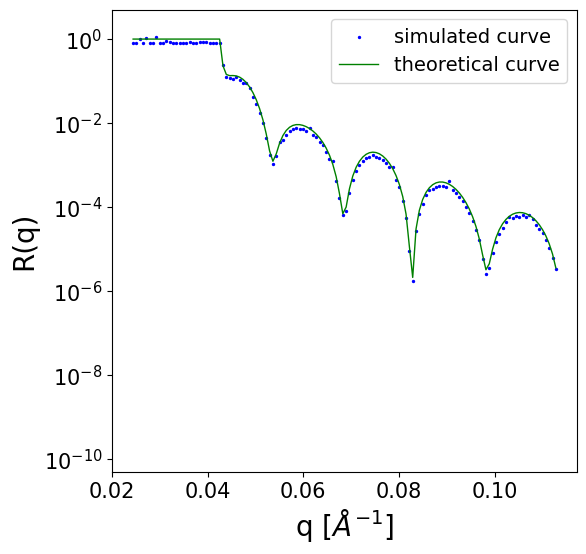

In [52]:
q = simulated_data['q_values']
scaled_noisy_curves = simulated_data['scaled_noisy_curves']
unscaled_noisy_curves = trainer.loader.curves_scaler.restore(scaled_noisy_curves)
unscaled_denoised_curve = simulated_data['curves']

def plot_refl_curve(i=0):
    fig, ax = plt.subplots(1,1,figsize=(6,6))

    ax.set_yscale('log')
    ax.set_ylim(0.5e-10, 5)

    ax.set_xlabel('q [$Å^{-1}$]', fontsize=20)
    ax.set_ylabel('R(q)', fontsize=20)

    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.tick_params(axis='both', which='minor', labelsize=15)
    
    y_tick_locations = [10**(-2*i) for i in range(6)]
    ax.yaxis.set_major_locator(plt.FixedLocator(y_tick_locations))
        
    ax.scatter(q[i].cpu().numpy(), unscaled_noisy_curves[i].cpu().numpy() + 1e-10, c='b', s=2, label='simulated curve')
    ax.plot(q[i].cpu().numpy(), unscaled_denoised_curve[i].cpu().numpy() + 1e-10, c='g', lw=1, label='theoretical curve')

    ax.legend(loc='upper right', fontsize=14)

plot_refl_curve(i=0)

This trained model corresponds to a 2 layer parameterization of the SLD profile (*in addition to the substrate*), which corresponds to 8 predicted film parameters:

In [53]:
n_layers = simulated_data['params'].max_layer_num
n_params = simulated_data['params'].num_params

print(f'Number of layers: {n_layers},  Number of film parameters: {n_params}')

Number of layers: 2,  Number of film parameters: 8


### Applying the model to synthetic data

The input to the neural network consists in the batch of reflectivity curves together with the prior bounds (minimum and maximum) for each film parameter. For experimental data, the prior bounds can be set according to the prior knowledge about the investigated thin film. In this example on simulated data, we use the prior bounds already sampled during the data generation process (i.e. meant for training the model) which ensures reasonable values for the prior bounds. 

In the `scaled_params` tensor the first 8 columns correspond to the *scaled* ground truth values of the film parameters, the next 8 columns to the *scaled* minimum bounds for the parameters and the last 8 to the *scaled* maximum bounds for the parameters. Thus, we select the last 16 columns as our input prior bounds:

In [54]:
scaled_bounds = simulated_data['scaled_params'][..., n_params:]

print(scaled_bounds.shape)

torch.Size([64, 16])


In the case of a model trained with the q values as an additional input to the network, we also need the scaled q values:

In [55]:
print(trainer.train_with_q_input)
scaled_q_values = trainer.loader.q_generator.scale_q(q).to(torch.float32).float() if trainer.train_with_q_input else None

True


The neural network can be accessed as the `model` attribute of the trainer. By providing the scaled reflectivity curves and the scaled prior bounds as inputs to the network (and any other additional inputs which might be required for a specific model), we obtain the predictions for the parameters. We should also make sure that the input is of the `float` datatype.

:::{note}
The neural network must be first set to evaluation mode, as this influences the functionality of some neural network components such as the batch normalization layers.
:::

In [56]:
with torch.no_grad():
    trainer.model.eval()
    
    scaled_predicted_params = trainer.model(
        curves=scaled_noisy_curves.float(),
        bounds=scaled_bounds.float(),
        q_values = scaled_q_values,
    )
    
print(scaled_predicted_params.shape)

torch.Size([64, 8])


Now we need to restore the scaled predicted parameters to their unscaled (physical) values. Since the predicted parameters are scaled with respect to the input prior bounds, these are also required for the rescaling. We can concatenate the `scaled_predicted_params` and `scaled_bounds` tensors along the last tensor axis and provide them as input to the `restore_params` method of the prior sampler object (which can be accessed as `trainer.loader.prior_sampler`), the output being an instance of the `BasicParams` class.

In [57]:
restored_predictions = trainer.loader.prior_sampler.restore_params(torch.cat([scaled_predicted_params, scaled_bounds], dim=-1))
print(restored_predictions)

BasicParams(batch_size=64, max_layer_num=2, device=cuda:0)


The physical predictions can then be accessed using the corresponding attribute for each parameter type.

In [58]:
pred_idx = 0

print(f'Predicted thicknesses: {restored_predictions.thicknesses[pred_idx]}')
print(f'Predicted roughnesses: {restored_predictions.roughnesses[pred_idx]}')
print(f'Predicted layer SLDs: {restored_predictions.slds[pred_idx]}')

Predicted thicknesses: tensor([160.4991, 371.9565], device='cuda:0', dtype=torch.float64)
Predicted roughnesses: tensor([25.2335, 17.1809, 16.4233], device='cuda:0', dtype=torch.float64)
Predicted layer SLDs: tensor([ 7.8177, 23.1593, 36.4681], device='cuda:0', dtype=torch.float64)


Based on the predictions, we can easily simulate the corresponding reflectivity curves by using the `reflectivity` method of the previously obtained `BasicParams` object, which takes the q values as input:

In [59]:
predicted_curves = restored_predictions.reflectivity(q)

We can observe the input reflectivity curves alongside the curves corresponding to the neural network prediction. Additionally, we can print the prediction for each parameter alongside its ground truth value and its prior bounds.

In [60]:
from reflectorch import get_param_labels, get_density_profiles

#@interact(i=(0, batch_size-1, 1))
def plot_refl_curve(i=0):
    fig, ax = plt.subplots(1,2,figsize=(12,6))

    ax[0].set_yscale('log')
    ax[0].set_ylim(0.5e-10, 5)

    ax[0].set_xlabel('q [$Å^{-1}$]', fontsize=20)
    ax[0].set_ylabel('R(q)', fontsize=20)

    ax[0].tick_params(axis='both', which='major', labelsize=15)
    ax[0].tick_params(axis='both', which='minor', labelsize=15)
    
    y_tick_locations = [10**(-2*i) for i in range(6)]
    ax[0].yaxis.set_major_locator(plt.FixedLocator(y_tick_locations))
        
    ax[0].plot(q[i].cpu().numpy(), predicted_curves[i].cpu().numpy() + 1e-10, c='r', lw=1, label='prediction')
    ax[0].scatter(q[i].cpu().numpy(), unscaled_noisy_curves[i].cpu().numpy() + 1e-10, facecolors='none', edgecolors='blue', s=8, label='input sim. curve')

    ax[0].legend(loc='upper right', fontsize=14)

    z_axis = torch.linspace(-200, 1000, 1000, device='cuda')
    _, sld_profile_gt, _ = get_density_profiles(
         simulated_data['params'].thicknesses, 
         simulated_data['params'].roughnesses,
         simulated_data['params'].slds,
         z_axis=z_axis)
    
    _, sld_profile_pred, _ = get_density_profiles(
         restored_predictions.thicknesses, 
         restored_predictions.roughnesses,
         restored_predictions.slds,
         z_axis=z_axis)
    
    ax[1].plot(z_axis.cpu().numpy(), sld_profile_pred[i].cpu().numpy(), c='r', label='prediction')
    ax[1].plot(z_axis.cpu().numpy(), sld_profile_gt[i].cpu().numpy(), c='b', label='ground truth')

    ax[1].set_xlabel('z [$Å$]', fontsize=20)
    ax[1].set_ylabel('SLD [$10^{-6} Å^{-2}$]', fontsize=20)
    ax[1].tick_params(axis='both', which='major', labelsize=15)
    ax[1].tick_params(axis='both', which='minor', labelsize=15)

    plt.tight_layout()


    for l, t, p, min_b, max_b in zip(
          get_param_labels(n_layers),
          simulated_data['params'].parameters[i], 
          restored_predictions.parameters[i], 
          restored_predictions.min_bounds[i], 
          restored_predictions.max_bounds[i]
          ):
         print(f'{l.ljust(14)} --> True: {t:.2f} Predicted: {p:.2f}  Input prior bounds: ({min_b:.2f}, {max_b:.2f})')

Thickness L1   --> True: 189.96 Predicted: 183.26  Input prior bounds: (127.10, 231.34)
Thickness L2   --> True: 436.75 Predicted: 429.23  Input prior bounds: (124.75, 483.20)
Roughness L1   --> True: 18.21 Predicted: 18.19  Input prior bounds: (5.05, 33.49)
Roughness L2   --> True: 13.98 Predicted: 13.86  Input prior bounds: (3.72, 58.31)
Roughness sub  --> True: 20.10 Predicted: 20.19  Input prior bounds: (2.49, 50.91)
SLD L1         --> True: 5.09 Predicted: 4.93  Input prior bounds: (0.74, 5.45)
SLD L2         --> True: 9.08 Predicted: 8.32  Input prior bounds: (7.92, 10.62)
SLD sub        --> True: 34.77 Predicted: 34.72  Input prior bounds: (32.72, 35.74)


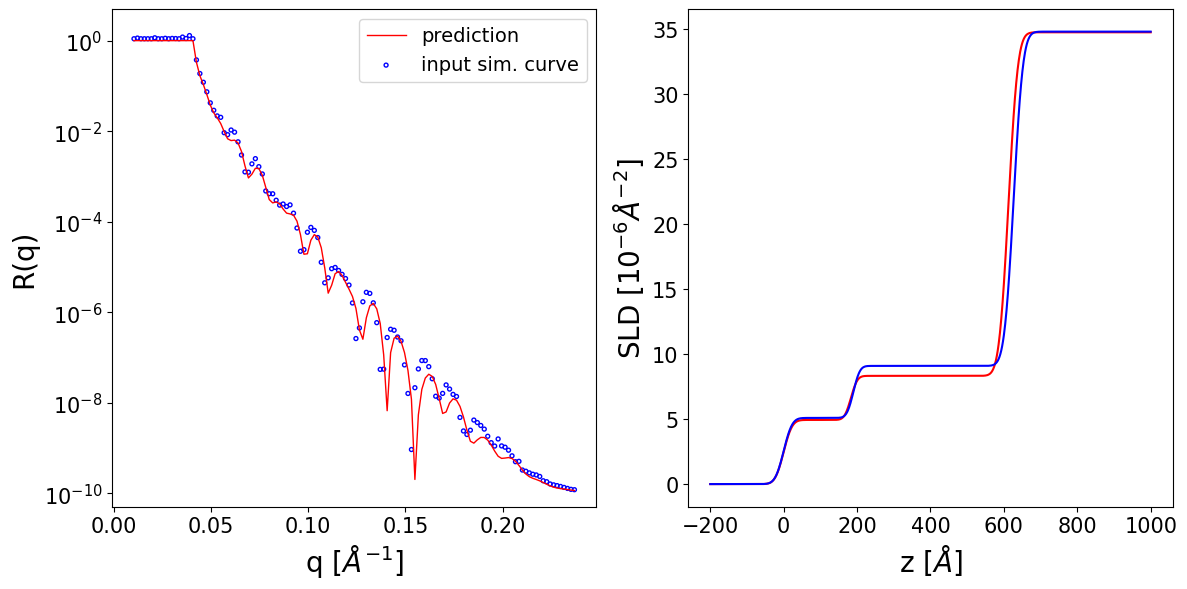

In [61]:
plot_refl_curve(i=15)

Thickness L1   --> True: 207.11 Predicted: 205.18  Input prior bounds: (55.55, 405.78)
Thickness L2   --> True: 78.21 Predicted: 81.19  Input prior bounds: (73.17, 99.58)
Roughness L1   --> True: 40.31 Predicted: 40.64  Input prior bounds: (16.38, 54.46)
Roughness L2   --> True: 26.57 Predicted: 25.93  Input prior bounds: (13.42, 31.85)
Roughness sub  --> True: 17.65 Predicted: 17.64  Input prior bounds: (9.80, 34.54)
SLD L1         --> True: 22.81 Predicted: 22.71  Input prior bounds: (20.52, 24.03)
SLD L2         --> True: 19.75 Predicted: 20.17  Input prior bounds: (19.57, 21.90)
SLD sub        --> True: 7.71 Predicted: 8.42  Input prior bounds: (7.11, 10.68)


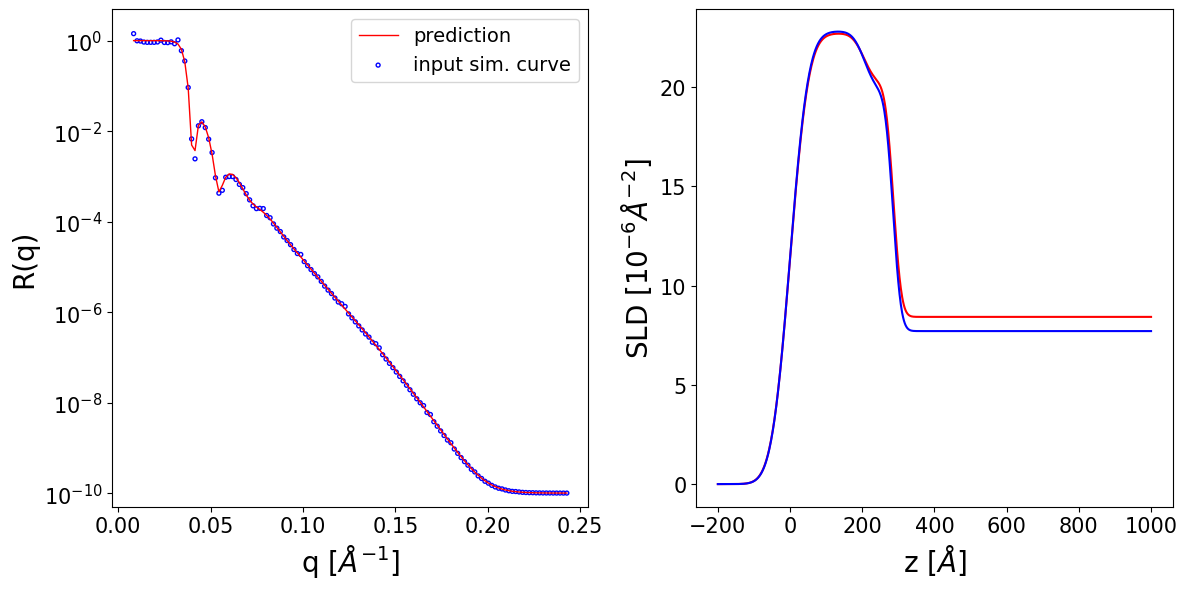

In [62]:
plot_refl_curve(i=30)

Thickness L1   --> True: 182.31 Predicted: 206.19  Input prior bounds: (13.00, 285.47)
Thickness L2   --> True: 348.19 Predicted: 348.29  Input prior bounds: (347.77, 348.94)
Roughness L1   --> True: 53.28 Predicted: 51.03  Input prior bounds: (42.37, 58.23)
Roughness L2   --> True: 4.53 Predicted: 4.45  Input prior bounds: (2.63, 9.84)
Roughness sub  --> True: 21.87 Predicted: 22.10  Input prior bounds: (17.86, 22.75)
SLD L1         --> True: 22.55 Predicted: 22.55  Input prior bounds: (21.77, 26.07)
SLD L2         --> True: 44.41 Predicted: 44.35  Input prior bounds: (44.14, 44.89)
SLD sub        --> True: 12.72 Predicted: 14.17  Input prior bounds: (12.72, 15.42)


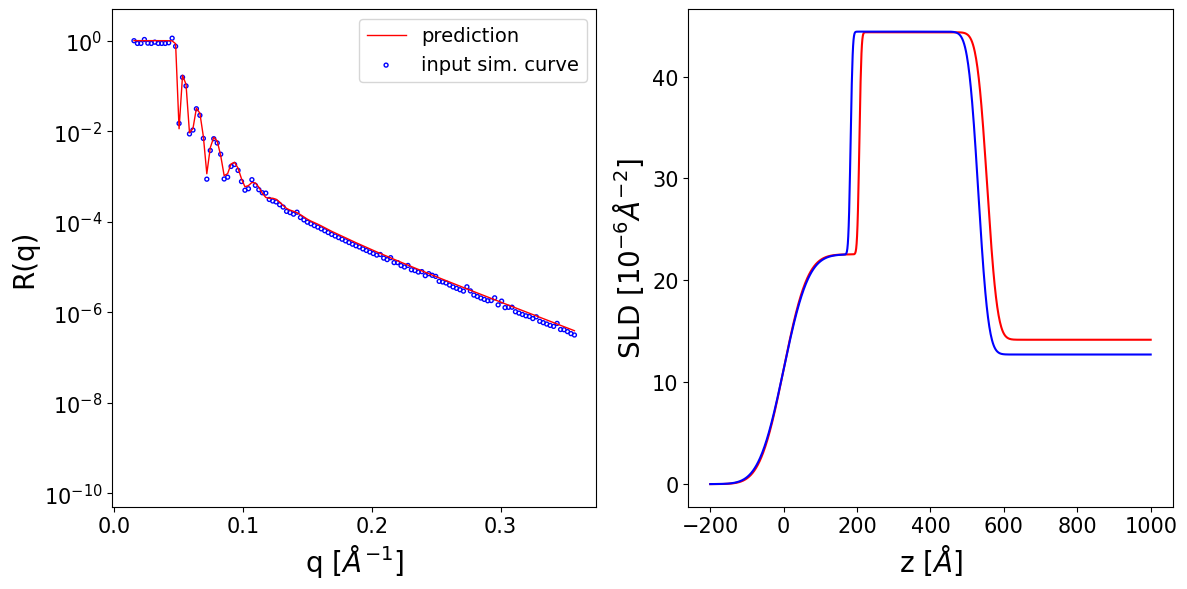

In [63]:
plot_refl_curve(i=45)

In [64]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

def init():
    ax[0].set_yscale('log')
    ax[0].set_ylim(0.5e-10, 5)
    ax[0].set_xlabel('q [$Å^{-1}$]', fontsize=20)
    ax[0].set_ylabel('R(q)', fontsize=20)
    ax[0].tick_params(axis='both', which='major', labelsize=15)
    ax[0].tick_params(axis='both', which='minor', labelsize=15)
    y_tick_locations = [10**(-2*i) for i in range(6)]
    ax[0].yaxis.set_major_locator(plt.FixedLocator(y_tick_locations))

    ax[1].set_xlabel('z [$Å$]', fontsize=20)
    ax[1].set_ylabel('SLD [$10^{-6} Å^{-2}$]', fontsize=20)
    ax[1].tick_params(axis='both', which='major', labelsize=15)
    ax[1].tick_params(axis='both', which='minor', labelsize=15)
    
    return []

def update(i):
    ax[0].clear()
    ax[1].clear()
    
    ax[0].set_yscale('log')
    ax[0].set_ylim(0.5e-10, 5)
    ax[0].set_xlabel('q [$Å^{-1}$]', fontsize=20)
    ax[0].set_ylabel('R(q)', fontsize=20)
    ax[0].tick_params(axis='both', which='major', labelsize=15)
    ax[0].tick_params(axis='both', which='minor', labelsize=15)
    y_tick_locations = [10**(-2*j) for j in range(6)]
    ax[0].yaxis.set_major_locator(plt.FixedLocator(y_tick_locations))
    
    ax[0].plot(q[i].cpu().numpy(), predicted_curves[i].cpu().numpy() + 1e-10, 
               c='r', lw=1, label='prediction')
    ax[0].scatter(q[i].cpu().numpy(), unscaled_noisy_curves[i].cpu().numpy() + 1e-10, 
                  facecolors='none', edgecolors='blue', s=8, label='input sim. curve') 
    ax[0].legend(loc='upper right', fontsize=14)

    z_axis = torch.linspace(-200, 1000, 1000, device='cpu')  # or device='cuda'
    _, sld_profile_gt, _ = get_density_profiles(
         simulated_data['params'].thicknesses[i:i+1].cpu(),
         simulated_data['params'].roughnesses[i:i+1].cpu(),
         simulated_data['params'].slds[i:i+1].cpu(),
         z_axis=z_axis)

    _, sld_profile_pred, _ = get_density_profiles(
         restored_predictions.thicknesses[i:i+1].cpu(),
         restored_predictions.roughnesses[i:i+1].cpu(),
         restored_predictions.slds[i:i+1].cpu(),
         z_axis=z_axis)
    
    ax[1].plot(z_axis.cpu().numpy(), sld_profile_pred[0].cpu().numpy(), 
               c='r', label='prediction')
    ax[1].plot(z_axis.cpu().numpy(), sld_profile_gt[0].cpu().numpy(), 
               c='b', label='ground truth')
    ax[1].set_xlabel('z [$Å$]', fontsize=20)
    ax[1].set_ylabel('SLD [$10^{-6} Å^{-2}$]', fontsize=20)
    ax[1].tick_params(axis='both', which='major', labelsize=15)
    ax[1].tick_params(axis='both', which='minor', labelsize=15)
    ax[1].legend(loc='upper right', fontsize=14)
    
    return []

anim = FuncAnimation(fig, update, frames=range(batch_size), 
                     init_func=init, blit=False)
plt.close(fig)

from IPython.display import HTML
HTML(anim.to_jshtml())